In [84]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib

In [85]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/*"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]

File 0: /Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/station_1.nc
<xarray.Dataset>
Dimensions:              (valid_time: 750192)
Coordinates:
    station              int64 ...
  * valid_time           (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-3...
    latitude             float64 ...
    longitude            float64 ...
    station_latitude     float64 ...
    station_longitude    float64 ...
    year                 (valid_time) int64 ...
Data variables: (12/15)
    u10                  (valid_time) float32 ...
    v10                  (valid_time) float32 ...
    d2m                  (valid_time) float32 ...
    t2m                  (valid_time) float32 ...
    msl                  (valid_time) float32 ...
    sst                  (valid_time) float32 ...
    ...                   ...
    mwp                  (valid_time) float32 ...
    swh                  (valid_time) float32 ...
    sea_level            (valid_time) float32 ...
    tide                 (vali

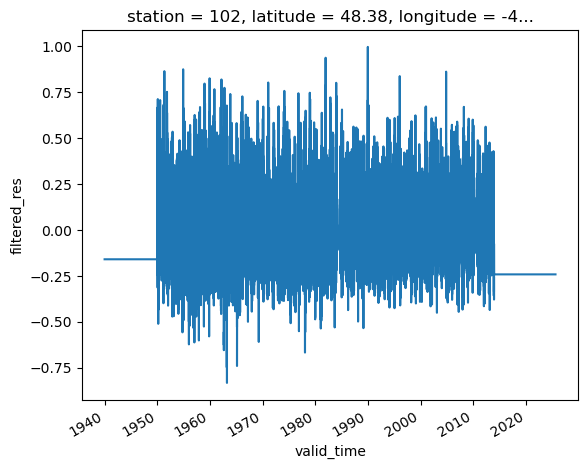

In [ ]:
import os
import sys
import numpy as np
import xarray as xr
import dask.array as da
import dask
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats
from scipy.signal import savgol_filter
from pathlib import Path
from tqdm import tqdm
import statsmodels.api as sm

# Known tidal periods and their names
tides_mapping = {
    12.42: 'M2',    # Principal lunar semi-diurnal
    12.00: 'S2',    # Solar semi-diurnal
    23.93: 'O1',    # Lunar diurnal
    25.82: 'P1',    # Solar diurnal
    12.66: 'K1',    # Lunar declinational
    11.97: 'K2',    # Lunar declinational
    6.33: 'N2',     # Second harmonic of M2
    6.21: 'NU2',    # Second harmonic of S2
    3.10: 'M4',     # Fourth harmonic of M2
    3.08: 'S4',     # Fourth harmonic of S2
    327.86: 'Mf',   # Annual
    661.2: 'Mm',    # Semi-annual
    4382.88: 'Mf',  # Long period tidal component
    8765.76: 'Ssa', # Semi-solar annual
}

# Function to remove tidal frequencies using FFT
def remove_tidal_frequencies(signal, time_numeric, tides_mapping):
    if np.any(np.isnan(signal)):
        nan_indices = np.isnan(signal)
        signal[nan_indices] = np.interp(time_numeric[nan_indices], time_numeric[~nan_indices], signal[~nan_indices])
        
    N = len(signal)
    freqs = np.fft.fftfreq(N, np.mean(np.diff(time_numeric)))
    fft_signal = np.fft.fft(signal)
    
    for period, tide_name in tides_mapping.items():
        freq_to_remove = 1 / period
        index_to_remove = np.argmin(np.abs(freqs - freq_to_remove))
        fft_signal[index_to_remove] = 0
        fft_signal[-index_to_remove] = 0

    filtered_signal = np.fft.ifft(fft_signal)
    filtered_signal = np.real(filtered_signal)
    
    return filtered_signal

# Apply Savitzky-Golay filter to smooth the signal
def apply_savitzky_golay(signal, window_length, polyorder):
    smoothed_signal = savgol_filter(signal, window_length, polyorder)
    return smoothed_signal

def detide_signal_with_savgol(dataset, tides_mapping, window_length=5, polyorder=3):
    res = dataset["residual"]

    time_values = pd.to_datetime(res["valid_time"].values)
    time_numeric = (time_values - time_values[0]) / np.timedelta64(1, "h")

    signal = res.values.squeeze().astype(float)

    # Interpolate NaNs BEFORE savgol
    if np.any(np.isnan(signal)):
        nans = np.isnan(signal)
        signal[nans] = np.interp(time_numeric[nans], time_numeric[~nans], signal[~nans])

    # Savitzky–Golay smoothing
    smoothed = savgol_filter(signal, window_length, polyorder)

    # Your current "FFT remove" line is effectively a no-op (fft then ifft returns the same signal)
    filtered = np.fft.ifft(np.fft.fft(smoothed)).real

    return filtered

res = datasets[2]["residual"]

filtered = detide_signal_with_savgol(datasets[2], tides_mapping, window_length=5, polyorder=3)

x_filtered = xr.DataArray(filtered, dims=res.dims, coords=res.coords, name="filtered_res")

x_filtered.plot()
plt.show()


In [82]:
import numpy as np

def fft_mag(y, dt_hours=1.0):
    y = np.asarray(y, float)
    y = y - np.nanmean(y)
    n = len(y)
    f = np.fft.rfftfreq(n, d=dt_hours)     # cycles/hour
    mag = np.abs(np.fft.rfft(y))
    return f, mag

# Example:
res = ds["residual"].values.squeeze()
det = x_filtered .values.squeeze()  # your harmonic detided series

# Use actual dt:
t = pd.to_datetime(ds["residual"]["valid_time"].values)
dt_h = np.median(np.diff(t) / np.timedelta64(1, "h"))

f0, m0 = fft_mag(res, dt_h)
f1, m1 = fft_mag(det, dt_h)

# Check magnitudes near known tidal frequencies:
targets_h = [12.4206, 12.0, 23.9345, 25.8193]
for p in targets_h:
    ft = 1.0/p
    i0 = np.argmin(np.abs(f0-ft))
    print(p, "hours | before:", m0[i0], "| after:", m1[i0])


12.4206 hours | before: nan | after: 118.04756760719238
12.0 hours | before: nan | after: 5.855245079491137e-14
23.9345 hours | before: nan | after: 135.34855426006976
25.8193 hours | before: nan | after: 1.329808065562073e-13


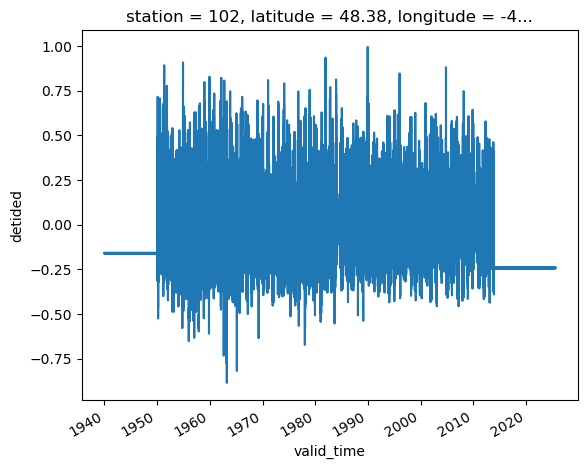

In [79]:
tides_period_hours = {
    "M2": 12.4206,
    "S2": 12.0000,
    "N2": 12.6583,
    "K2": 11.9672,
    "K1": 23.9345,
    "O1": 25.8193,
    "P1": 24.0659,
}

import numpy as np
import pandas as pd
import xarray as xr

def detide_harmonic_regression(res_da: xr.DataArray, periods_h: dict, time_coord="valid_time"):
    # Extract time in hours since start
    t = pd.to_datetime(res_da[time_coord].values)
    tn = (t - t[0]) / np.timedelta64(1, "h")
    y = np.asarray(res_da.values).squeeze().astype(float)

    if y.ndim != 1:
        raise ValueError(f"Expected 1D time series; got shape {y.shape}. Select a single point first.")

    # Fill NaNs (regression cannot handle NaNs)
    if np.any(np.isnan(y)):
        n = np.isnan(y)
        if n.all():
            return xr.full_like(res_da, np.nan).rename("detided")
        y[n] = np.interp(tn[n], tn[~n], y[~n])

    # Build design matrix: [1, sin(2πft), cos(2πft), ...]
    cols = [np.ones_like(tn)]
    for name, p in periods_h.items():
        f = 1.0 / p  # cycles per hour
        w = 2 * np.pi * f
        cols.append(np.sin(w * tn))
        cols.append(np.cos(w * tn))
    X = np.column_stack(cols)

    # Least squares fit
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    tide_fit = X @ beta
    detided = y - (tide_fit - beta[0])  # subtract tidal components, keep mean

    return xr.DataArray(detided, dims=res_da.dims, coords=res_da.coords, name="detided")


ds = datasets[2]
res = ds["residual"]

x_detided = detide_harmonic_regression(res, tides_period_hours)

x_detided.plot()
plt.show()


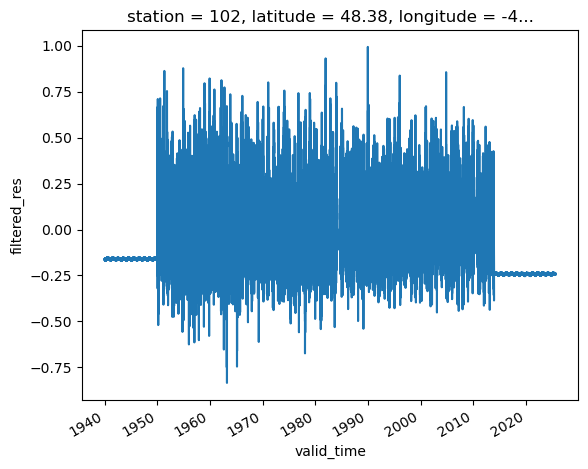

In [ ]:


def detide_signal_with_savgol(dataset, tides_mapping, window_length=5, polyorder=3):
    res = dataset["residual"]

    # time axis (hours since start)
    time_values = pd.to_datetime(res["valid_time"].values)
    time_numeric = (time_values - time_values[0]) / np.timedelta64(1, "h")

    y = np.asarray(res.values).squeeze().astype(float)

    # basic safety: ensure 1D series
    if y.ndim != 1:
        raise ValueError(
            f"Expected a 1D time series after selection; got shape {y.shape}. "
            "Select a single location/station first (e.g., .sel(...) or .isel(...))."
        )

    # Fill NaNs before filtering / FFT
    if np.any(np.isnan(y)):
        n = np.isnan(y)
        if n.all():
            return np.full_like(y, np.nan)
        y[n] = np.interp(time_numeric[n], time_numeric[~n], y[~n])

    # Make window_length valid: odd and <= len(y)
    wl = int(window_length)
    if wl % 2 == 0:
        wl += 1
    if wl > len(y):
        wl = len(y) if len(y) % 2 == 1 else len(y) - 1
    if wl < polyorder + 2:
        wl = polyorder + 2
        if wl % 2 == 0:
            wl += 1

    smoothed = savgol_filter(y, wl, polyorder)

    # Actual tidal frequency removal
    detided = remove_tidal_frequencies(smoothed, time_numeric, tides_mapping)

    # Return as DataArray matching original residual coords/dims
    return xr.DataArray(detided, dims=res.dims, coords=res.coords, name="filtered_res")


# Usage
ds = datasets[2]
x_filtered = detide_signal_with_savgol(ds, tides_mapping, window_length=5, polyorder=3)

x_filtered.plot()
plt.show()


In [80]:
x = x_filtered

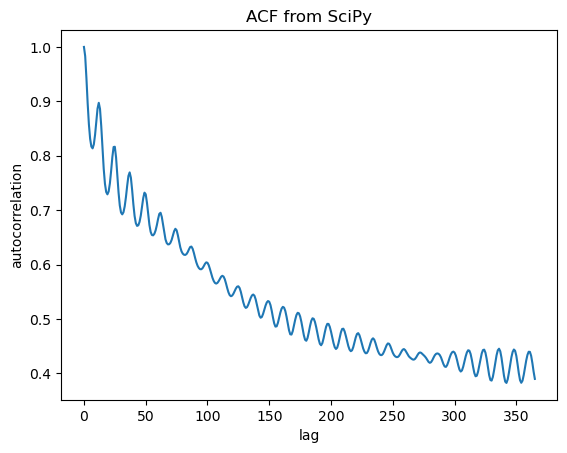

In [ ]:
def autocorr_scipy_lags(x, max_lag):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    x = x - x.mean()

    corr = correlate(x, x, mode='full')
    corr = corr[corr.size // 2 : corr.size // 2 + max_lag + 1]
    corr /= corr[0]

    return corr

lags = 365
acf_vals = autocorr_scipy_lags(x, lags)
plt.plot(acf_vals)
plt.title("ACF from SciPy")
plt.xlabel("lag")
plt.ylabel("autocorrelation")
plt.show()

In [72]:
s = pd.Series(x)
s.autocorr(lag = 13)

0.8860901802928673

In [73]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

Lag where second derivative is closest to zero: 246


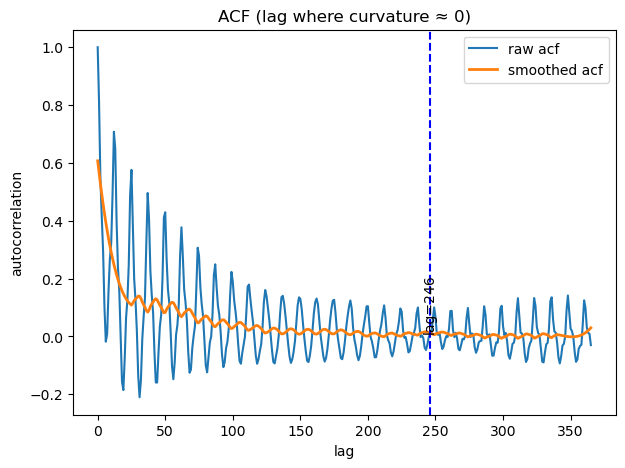

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, savgol_filter

def autocorr_scipy_lags(x, max_lag):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    x = x - x.mean()

    corr = correlate(x, x, mode='full')
    corr = corr[corr.size // 2 : corr.size // 2 + max_lag + 1]
    corr /= corr[0]
    return corr

x = datasets[100].residual

max_lag = 365
acf_vals = autocorr_scipy_lags(x, max_lag)

# ---- smooth to remove fine oscillations ----
smooth = savgol_filter(acf_vals, window_length=51, polyorder=3)

# ---- compute second derivative ----
second = np.gradient(np.gradient(smooth))

# ignore noisy endpoints
edge = 5
idx_range = np.arange(edge, len(second) - edge)

# ---- lag where curvature is closest to zero ----
flat_curv_idx_rel = np.argmin(np.abs(second[idx_range]))
flat_curv_lag = idx_range[flat_curv_idx_rel]

print("Lag where second derivative is closest to zero:", flat_curv_lag)

# ---- plot ----
plt.figure(figsize=(7,5))
plt.plot(acf_vals, label="raw acf")
plt.plot(smooth, label="smoothed acf", linewidth=2)

plt.axvline(flat_curv_lag, linestyle="--", color="blue")
plt.text(flat_curv_lag, smooth[flat_curv_lag],
         f"lag={flat_curv_lag}", rotation=90,
         va="bottom", ha="center")

plt.title("ACF (lag where curvature ≈ 0)")
plt.xlabel("lag")
plt.ylabel("autocorrelation")
plt.legend()
plt.show()


First lag where acf < 0.1: 6


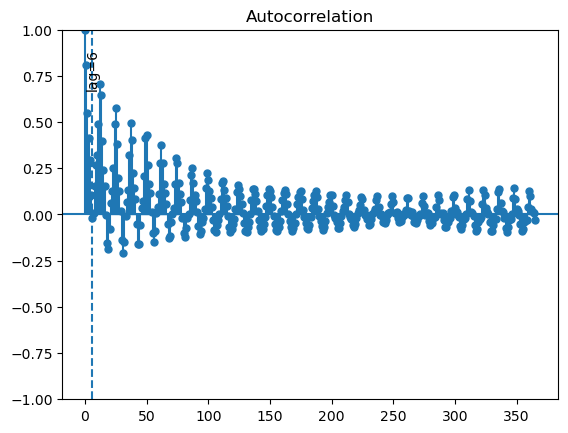

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

max_lag = 365
threshold = 0.1

# 1. Compute ACF values
acf_vals = acf(
    x,
    nlags=max_lag,
    missing="drop",
    fft=False,
    adjusted=False,
)

# 2. Find the first lag (excluding lag 0) where autocorrelation < 0.1
lags = np.arange(len(acf_vals))
mask = np.where(acf_vals < threshold)[0]
mask = mask[mask > 0]   # ignore lag 0
first_below = mask[0] if len(mask) > 0 else None

print("First lag where acf < 0.1:", first_below)

# 3. Plot ACF and mark that lag
fig, ax = plt.subplots()
plot_acf(
    x,
    lags=max_lag,
    missing="drop",
    alpha=0.05,
    use_vlines=True,
    adjusted=False,
    fft=False,
    title="Autocorrelation",
    zero=True,
    auto_ylims=False,
    bartlett_confint=True,
    ax=ax,
)

if first_below is not None:
    ax.axvline(first_below, linestyle="--")
    ax.text(first_below, 0.9, f"lag={first_below}", rotation=90,
            va="top", ha="center")
plt.show()


In [7]:
import numpy as np
from scipy.signal import correlate

def autocorr_scipy(x):
    x = np.asarray(x)
    x = x[~np.isnan(x)]    # remove NaNs
    x = x - x.mean()

    corr = correlate(x, x, mode='full')
    corr = corr[corr.size // 2:]  # keep lags ≥ 0
    corr /= corr[0]               # normalize

    return corr


In [8]:
acf_vals = autocorr_scipy(x)


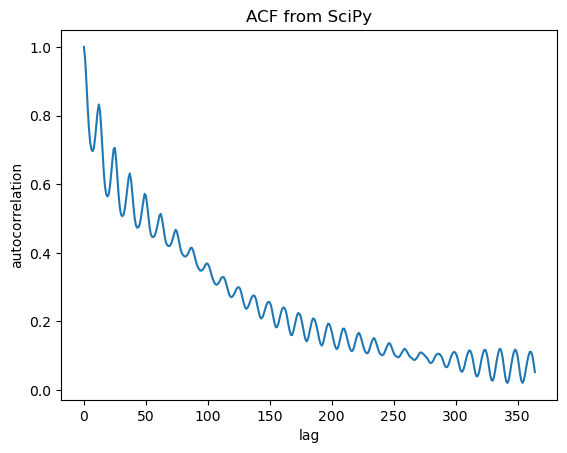

In [9]:
import matplotlib.pyplot as plt
plt.plot(acf_vals[:365])
plt.title("ACF from SciPy")
plt.xlabel("lag")
plt.ylabel("autocorrelation")
plt.show()

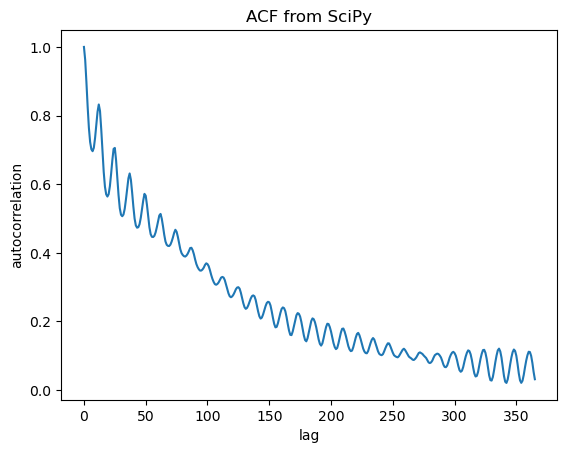

In [ ]:
def autocorr_scipy_lags(x, max_lag):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    x = x - x.mean()

    corr = correlate(x, x, mode='full')
    corr = corr[corr.size // 2 : corr.size // 2 + max_lag + 1]
    corr /= corr[0]

    return corr
lags = 365
acf_vals = autocorr_scipy_lags(x, lags)
plt.plot(acf_vals)
plt.title("ACF from SciPy")
plt.xlabel("lag")
plt.ylabel("autocorrelation")
plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    x,
    lags=365,
    missing="drop",        # or "conservative"
    alpha=0.05,
    use_vlines=True,
    adjusted=False,
    fft=False,
    title="Autocorrelation",
    zero=True,
    auto_ylims=False,
    bartlett_confint=True,
)